In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/veron/Desktop/clinical appts project/data/cleaned_appointments.csv')
df

,patient_id_fixed,patient_id,patient_name,age,doctor,department,gender_fixed,follow_up_required_fix,billing_amount_fixed,appointment_date_final,booking_date_final,age_bracket,lead_time_category
0,1,1074,Megan Strickland,69,Brandon Lewis,Orthopedics,Female,Yes,375.24,2025-05-23,2024-06-12,Elderly,Moderate Wait
1,2,1067,Amanda Schroeder,79,Deanna Edwards,Neurology,Male,Yes,221.64,2025-11-30,2024-08-05,Elderly,Long Wait
2,3,1072,Anthony Mcpherson,47,Karen Parsons,General,Female,No,1.03,2025-05-18,2024-09-09,Middle Aged,Standard Wait
3,4,1057,Joe Sharp,78,Kimberly Fields,General,Unknown,Yes,200.42,2025-09-26,2025-08-31,Elderly,Standard Wait
4,5,1018,Alexander Harris,22,Jim Jones,Cardiology,Female,No,107.91,2025-10-30,2024-12-29,Young Adult,Moderate Wait
...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,660,1068,Aaron Holder,19,Lauren Ayers,General,Male,Yes,4.53,2026-01-26,2024-11-28,Young Adult,Long Wait
660,661,1082,Thomas Roman,64,Robert Bass,General,Female,Yes,2.41,2025-09-14,2024-07-15,Middle Aged,Long Wait
661,662,1008,Jack Cooper,67,Christopher Smith,General,Female,No,2.93,2025-04-09,2024-06-20,Elderly,Moderate Wait
662,663,1022,Christopher Brown,28,Kimberly Johnson,Neurology,Unknown,No,196.19,2026-02-13,2024-06-13,Young Adult,Extreme Wait


In [3]:
print(plt.style.available)
plt.style.use('seaborn-v0_8-muted')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [4]:
df=df.sort_values(by='age')
df

,patient_id_fixed,patient_id,patient_name,age,doctor,department,gender_fixed,follow_up_required_fix,billing_amount_fixed,appointment_date_final,booking_date_final,age_bracket,lead_time_category
613,614,1012,Ian Weaver,18,Audrey Torres,Neurology,Female,Yes,3.81,2026-01-19,2025-06-01,Young Adult,Standard Wait
24,25,1030,Patrick Saunders,18,Casey Wagner,Orthopedics,Male,No,2.51,2025-09-11,2024-10-05,Young Adult,Moderate Wait
597,598,1083,Jessica Rodriguez,18,Jeffrey Martin,Neurology,Male,Yes,4.94,2025-04-21,2024-09-04,Young Adult,Standard Wait
562,563,1073,Leslie Medina,18,Matthew Morse,Orthopedics,Female,Yes,623.48,2025-08-17,2025-06-25,Young Adult,Standard Wait
64,65,1058,Traci Chandler,18,Tyler Carter,General,Female,No,467.34,2026-02-04,2024-12-10,Young Adult,Long Wait
...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,268,1001,Robert Hampton,90,Kevin Wilkinson,Neurology,Male,No,410.44,2025-11-12,2025-09-04,Elderly,Standard Wait
236,237,1014,Jennifer Schwartz,90,Mrs. Michelle Ramsey,Orthopedics,Unknown,No,517.03,2026-02-12,2024-08-14,Elderly,Extreme Wait
231,232,1058,Brianna Mcpherson,90,Nathaniel Thompson,General,Male,Yes,139.20,2025-05-13,2024-06-17,Elderly,Moderate Wait
17,18,1069,Jennifer Aguirre,90,Richard Huang,Neurology,Male,No,0.87,2025-10-14,2024-05-28,Elderly,Long Wait


In [37]:
df_age = df.groupby(['age_bracket','follow_up_required_fix'])['patient_id_fixed'].count()
df_age = df_age.unstack()
df_age

follow_up_required_fix,No,Yes
age_bracket,,
Elderly,101,142
Middle Aged,104,111
Young Adult,96,110


In [70]:
df_age_yes_rate = df_age['Yes']/(df_age['Yes'] + df_age['No'])
df_age_yes_rate

age_bracket
Elderly        0.584362
Middle Aged    0.516279
Young Adult    0.533981
dtype: float64

<Axes: title={'center': 'Age Bracket and Follow Up Required Frequency'}, xlabel='Age Bracket', ylabel='Frequency'>

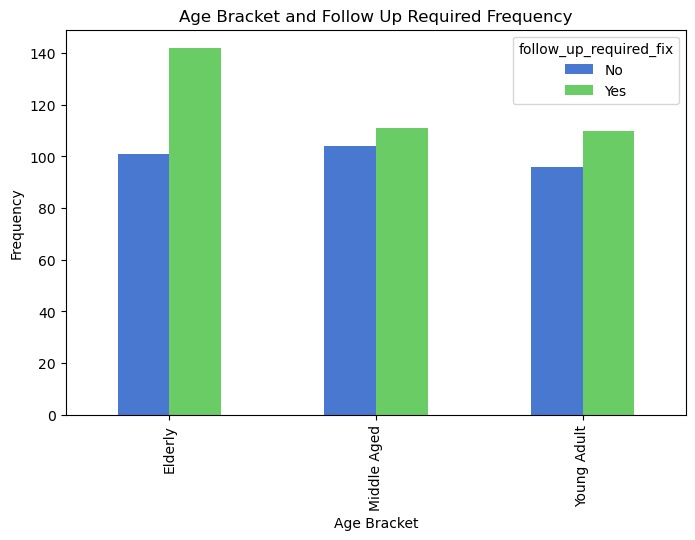

In [62]:
df_age.plot.bar(xlabel='Age Bracket', ylabel='Frequency', title='Age Bracket and Follow Up Required Frequency', figsize=(8,5))

<Axes: title={'center': 'Age and Follow Up Required Yes Rate'}, xlabel='Age', ylabel='Yes Rate'>

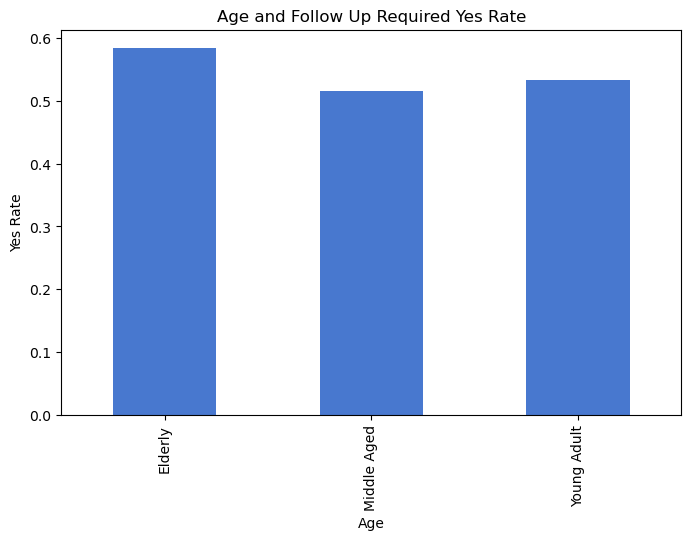

In [71]:
df_age_yes_rate.plot.bar(xlabel='Age', ylabel='Yes Rate', title='Age and Follow Up Required Yes Rate', figsize=(8,5))

In [39]:
df_gender = df.groupby(['gender_fixed','follow_up_required_fix'])['patient_id_fixed'].count()
df_gender = df_gender.unstack()
df_gender

follow_up_required_fix,No,Yes
gender_fixed,,
Female,98,131
Male,98,129
Unknown,105,103


In [69]:
df_gender_yes_rate = df_gender['Yes']/(df_gender['Yes'] + df_gender['No'])
df_gender_yes_rate

gender_fixed
Female     0.572052
Male       0.568282
Unknown    0.495192
dtype: float64

<Axes: title={'center': 'Gender and Follow Up Required Frequency'}, xlabel='Gender', ylabel='Frequency'>

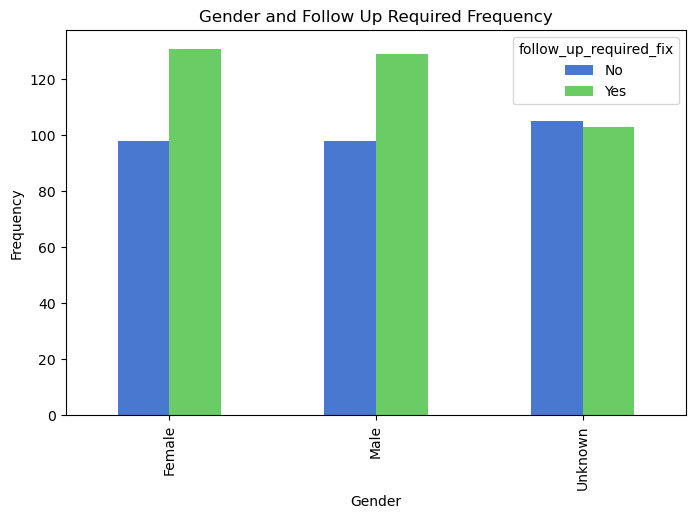

In [61]:
df_gender.plot.bar(xlabel='Gender', ylabel='Frequency', title='Gender and Follow Up Required Frequency', figsize=(8,5))

<Axes: title={'center': 'Gender and Follow Up Required Yes Rate'}, xlabel='Gender', ylabel='Yes Rate'>

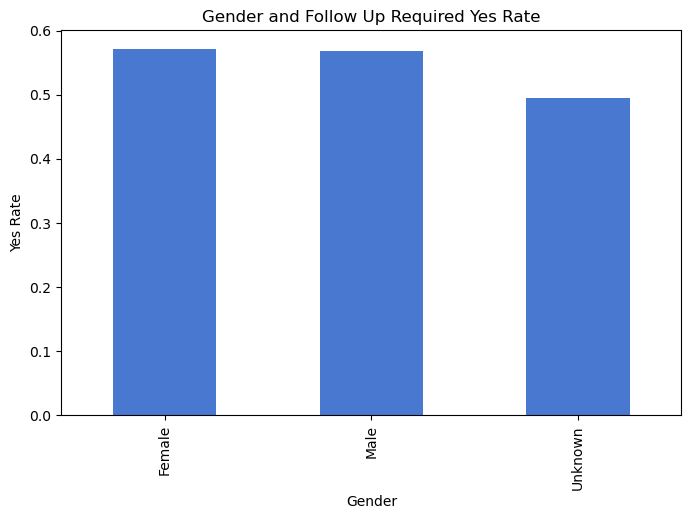

In [73]:
df_gender_yes_rate.plot.bar(xlabel='Gender', ylabel='Yes Rate', title='Gender and Follow Up Required Yes Rate', figsize=(8,5))

In [29]:
df.groupby('follow_up_required_fix')['billing_amount_fixed'].mean()

follow_up_required_fix
No     224.668671
Yes    223.396474
Name: billing_amount_fixed, dtype: float64

In [67]:
df_department = df.groupby(['department','follow_up_required_fix'])['patient_id_fixed'].count()
df_department = df_department.unstack()
df_department

follow_up_required_fix,No,Yes
department,,
Cardiology,76,79
General,63,88
Neurology,76,105
Orthopedics,86,91


In [68]:
df_department_yes_rate = df_department['Yes']/(df_department['Yes'] + df_department['No'])
df_department_yes_rate

department
Cardiology     0.509677
General        0.582781
Neurology      0.580110
Orthopedics    0.514124
dtype: float64

<Axes: title={'center': 'Department and Follow Up Required Frequency'}, xlabel='Department', ylabel='Frequency'>

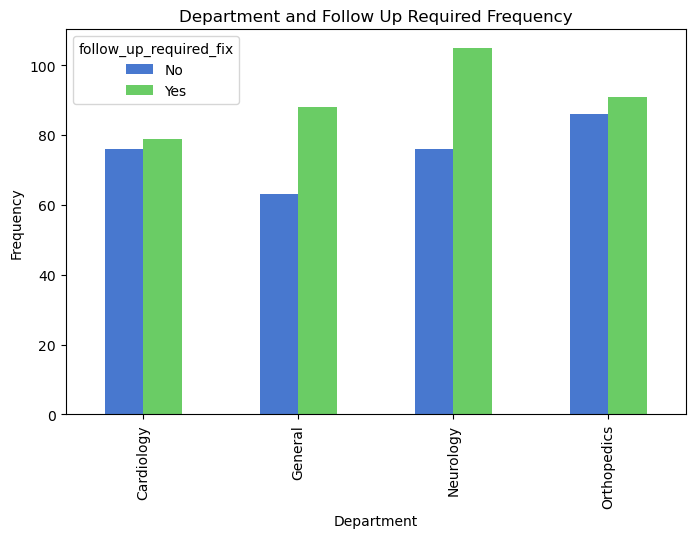

In [48]:
df_department.plot.bar(xlabel='Department', ylabel='Frequency', title='Department and Follow Up Required Frequency', figsize=(8,5))

<Axes: title={'center': 'Department and Follow Up Required Yes Rate'}, xlabel='Department', ylabel='Yes Rate'>

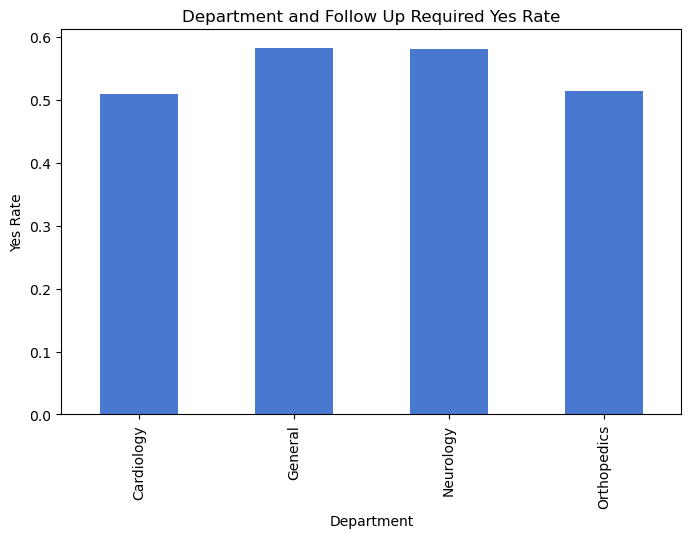

In [66]:
df_department_yes_rate.plot.bar(xlabel='Department', ylabel='Yes Rate', title='Department and Follow Up Required Yes Rate', figsize=(8,5))

In [43]:
df_category = df.groupby(['lead_time_category','follow_up_required_fix'])['patient_id_fixed'].count()
df_category = df_category.unstack()
df_category

follow_up_required_fix,No,Yes
lead_time_category,,
Extreme Wait,32,39
Long Wait,42,46
Moderate Wait,72,92
Standard Wait,155,186


In [74]:
df_category_yes_rate = df_category['Yes']/(df_category['Yes'] + df_category['No'])
df_category_yes_rate

lead_time_category
Extreme Wait     0.549296
Long Wait        0.522727
Moderate Wait    0.560976
Standard Wait    0.545455
dtype: float64

<Axes: title={'center': 'Lead Time Category and Follow Up Required Frequency'}, xlabel='Lead Time Category', ylabel='Frequency'>

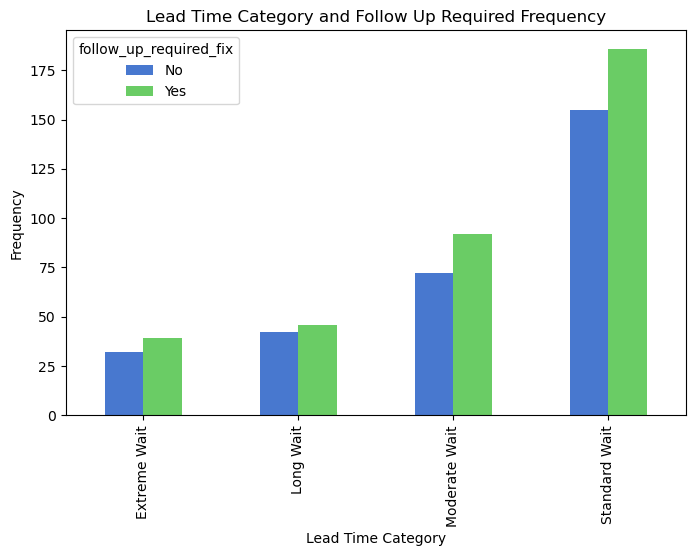

In [49]:
df_category.plot.bar(xlabel='Lead Time Category', ylabel='Frequency', title='Lead Time Category and Follow Up Required Frequency', figsize=(8,5))

<Axes: title={'center': 'Lead Time Category and Follow Up Required Yes Rate'}, xlabel='Lead Time Category', ylabel='Yes Rate'>

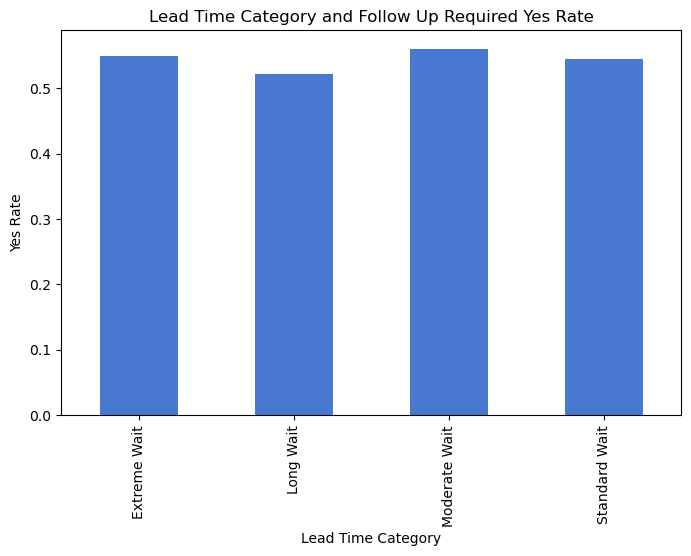

In [75]:
df_category_yes_rate.plot.bar(xlabel='Lead Time Category', ylabel='Yes Rate', title='Lead Time Category and Follow Up Required Yes Rate', figsize=(8,5))

In [45]:
doctor_counts = df['doctor'].value_counts()
doctors_w_multiple = doctor_counts[doctor_counts>1]
doctors_w_multiple

doctor
Jennifer Adams       2
Nancy Hernandez      2
James Aguilar        2
Jennifer Carroll     2
Benjamin Brown       2
Nancy Wilson         2
Wesley Johnson       2
Christopher Smith    2
Name: count, dtype: int64